Installing Required Libraries

In [ ]:
!pip install imbalanced-learn

Importing Libraries 

In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, RobustScaler, FunctionTransformer
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTENC

Loading Dataset into a Dataframe

In [2]:
data = pd.read_csv("../data/raw/diabetes_dataset.csv")

In [4]:
#First 5 rows

data.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [8]:
#Last 5 rows

data.tail()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0
99999,52,Female,White,Postgraduate,Middle,Employed,Never,1,248,2.7,...,31,183,87,91,142,15.93,5.73,27.9,Pre-Diabetes,0


In [9]:
#Shape of dataframe

data.shape

(100000, 31)

In [10]:
#Column names and data types

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

Data types are correct and do not need fixing. 

In [21]:
#Statistical Summary of numerical columns

data.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [22]:
#Statistical summary of catagorical columns

data.describe(include = "object")

,gender,ethnicity,education_level,income_level,employment_status,smoking_status,diabetes_stage
count,100000,100000,100000,100000,100000,100000,100000
unique,3,5,4,5,4,3,5
top,Female,White,Highschool,Middle,Employed,Never,Type 2
freq,50216,44997,44891,35152,60175,59813,59774


In [13]:
#Checking for missing values

data.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


There are no missing values in the dataset. 

In [16]:
#Checking for duplicate rows

data.duplicated().sum()

0

There are no duplicate rows in dataset. 

In [23]:
#Checking unique values of each column for any inconsistencies 

def see_uniques(data):
    for col in data.columns:
        print(f"Column Name: {col}")
        print(f"Number of unique values: {data[col].nunique()}")
        print(data[col].unique())
        print("\n---------------------------------------------\n")
        
see_uniques(data)

Column Name: age
Number of unique values: 73
[58 48 60 74 46 75 62 42 59 43 54 19 22 41 34 55 35 27 73 51 52 32 56 40
 45 80 50 33 63 30 53 29 26 38 67 44 39 66 65 37 47 31 72 49 18 89 68 28
 85 25 71 24 61 69 57 36 90 64 87 20 84 78 70 76 83 79 23 81 77 21 86 82
 88]

---------------------------------------------

Column Name: gender
Number of unique values: 3
['Male' 'Female' 'Other']

---------------------------------------------

Column Name: ethnicity
Number of unique values: 5
['Asian' 'White' 'Hispanic' 'Black' 'Other']

---------------------------------------------

Column Name: education_level
Number of unique values: 4
['Highschool' 'Graduate' 'Postgraduate' 'No formal']

---------------------------------------------

Column Name: income_level
Number of unique values: 5
['Lower-Middle' 'Middle' 'Low' 'Upper-Middle' 'High']

---------------------------------------------

Column Name: employment_status
Number of unique values: 4
['Employed' 'Unemployed' 'Retired' 'Student']

--

There do not appear to be any incorrect values or inconsistent labels. 

Catagorical features such as gender require one-hot encoding. 

Expolatory Data Analysis 

Checking distribution of target variables


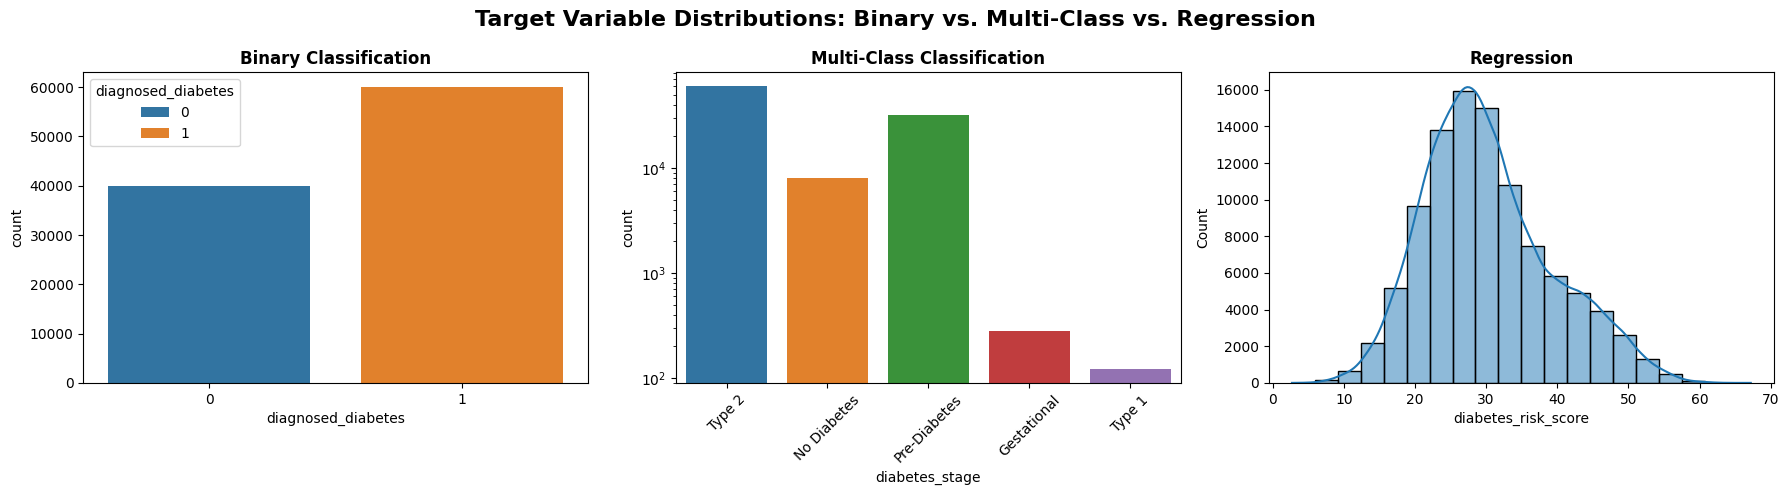

In [106]:
#Plotting subplots to visual distributions

fig, axes = plt.subplots(1, 3, figsize = (18, 5))


#Binary Classification
sns.countplot(data = data,
             x = "diagnosed_diabetes",
             hue = "diagnosed_diabetes",
             ax = axes[0])
axes[0].set_title("Binary Classification", fontweight = "bold")


#Multi-Class Classification
sns.countplot(data = data,
             x = "diabetes_stage",
             hue = "diabetes_stage",
             ax = axes[1])
axes[1].set_yscale('log')
axes[1].set_title("Multi-Class Classification", fontweight = "bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation = 45)


#Regression
sns.histplot(data = data,
            x = "diabetes_risk_score",
            bins = 20,
            kde = True,
            ax = axes[2])
axes[2].set_title("Regression", fontweight = "bold")
    
    
plt.suptitle("Target Variable Distributions: Binary vs. Multi-Class vs. Regression", fontweight = "bold", fontsize = 16)
plt.tight_layout()

Binary: The 60/40 split is well balanced. No resampling is required.

Multi-Class: There is a severe imbalance, with Gestational and Type 1 samples extremely few in number. 
             Approach: Using SMOTE-NC to oversample rare classes. 

Regression: The target variable (i.e. diabetes risk score) is approximately normal with a mean of 30. 

Checking Distributions of Features 

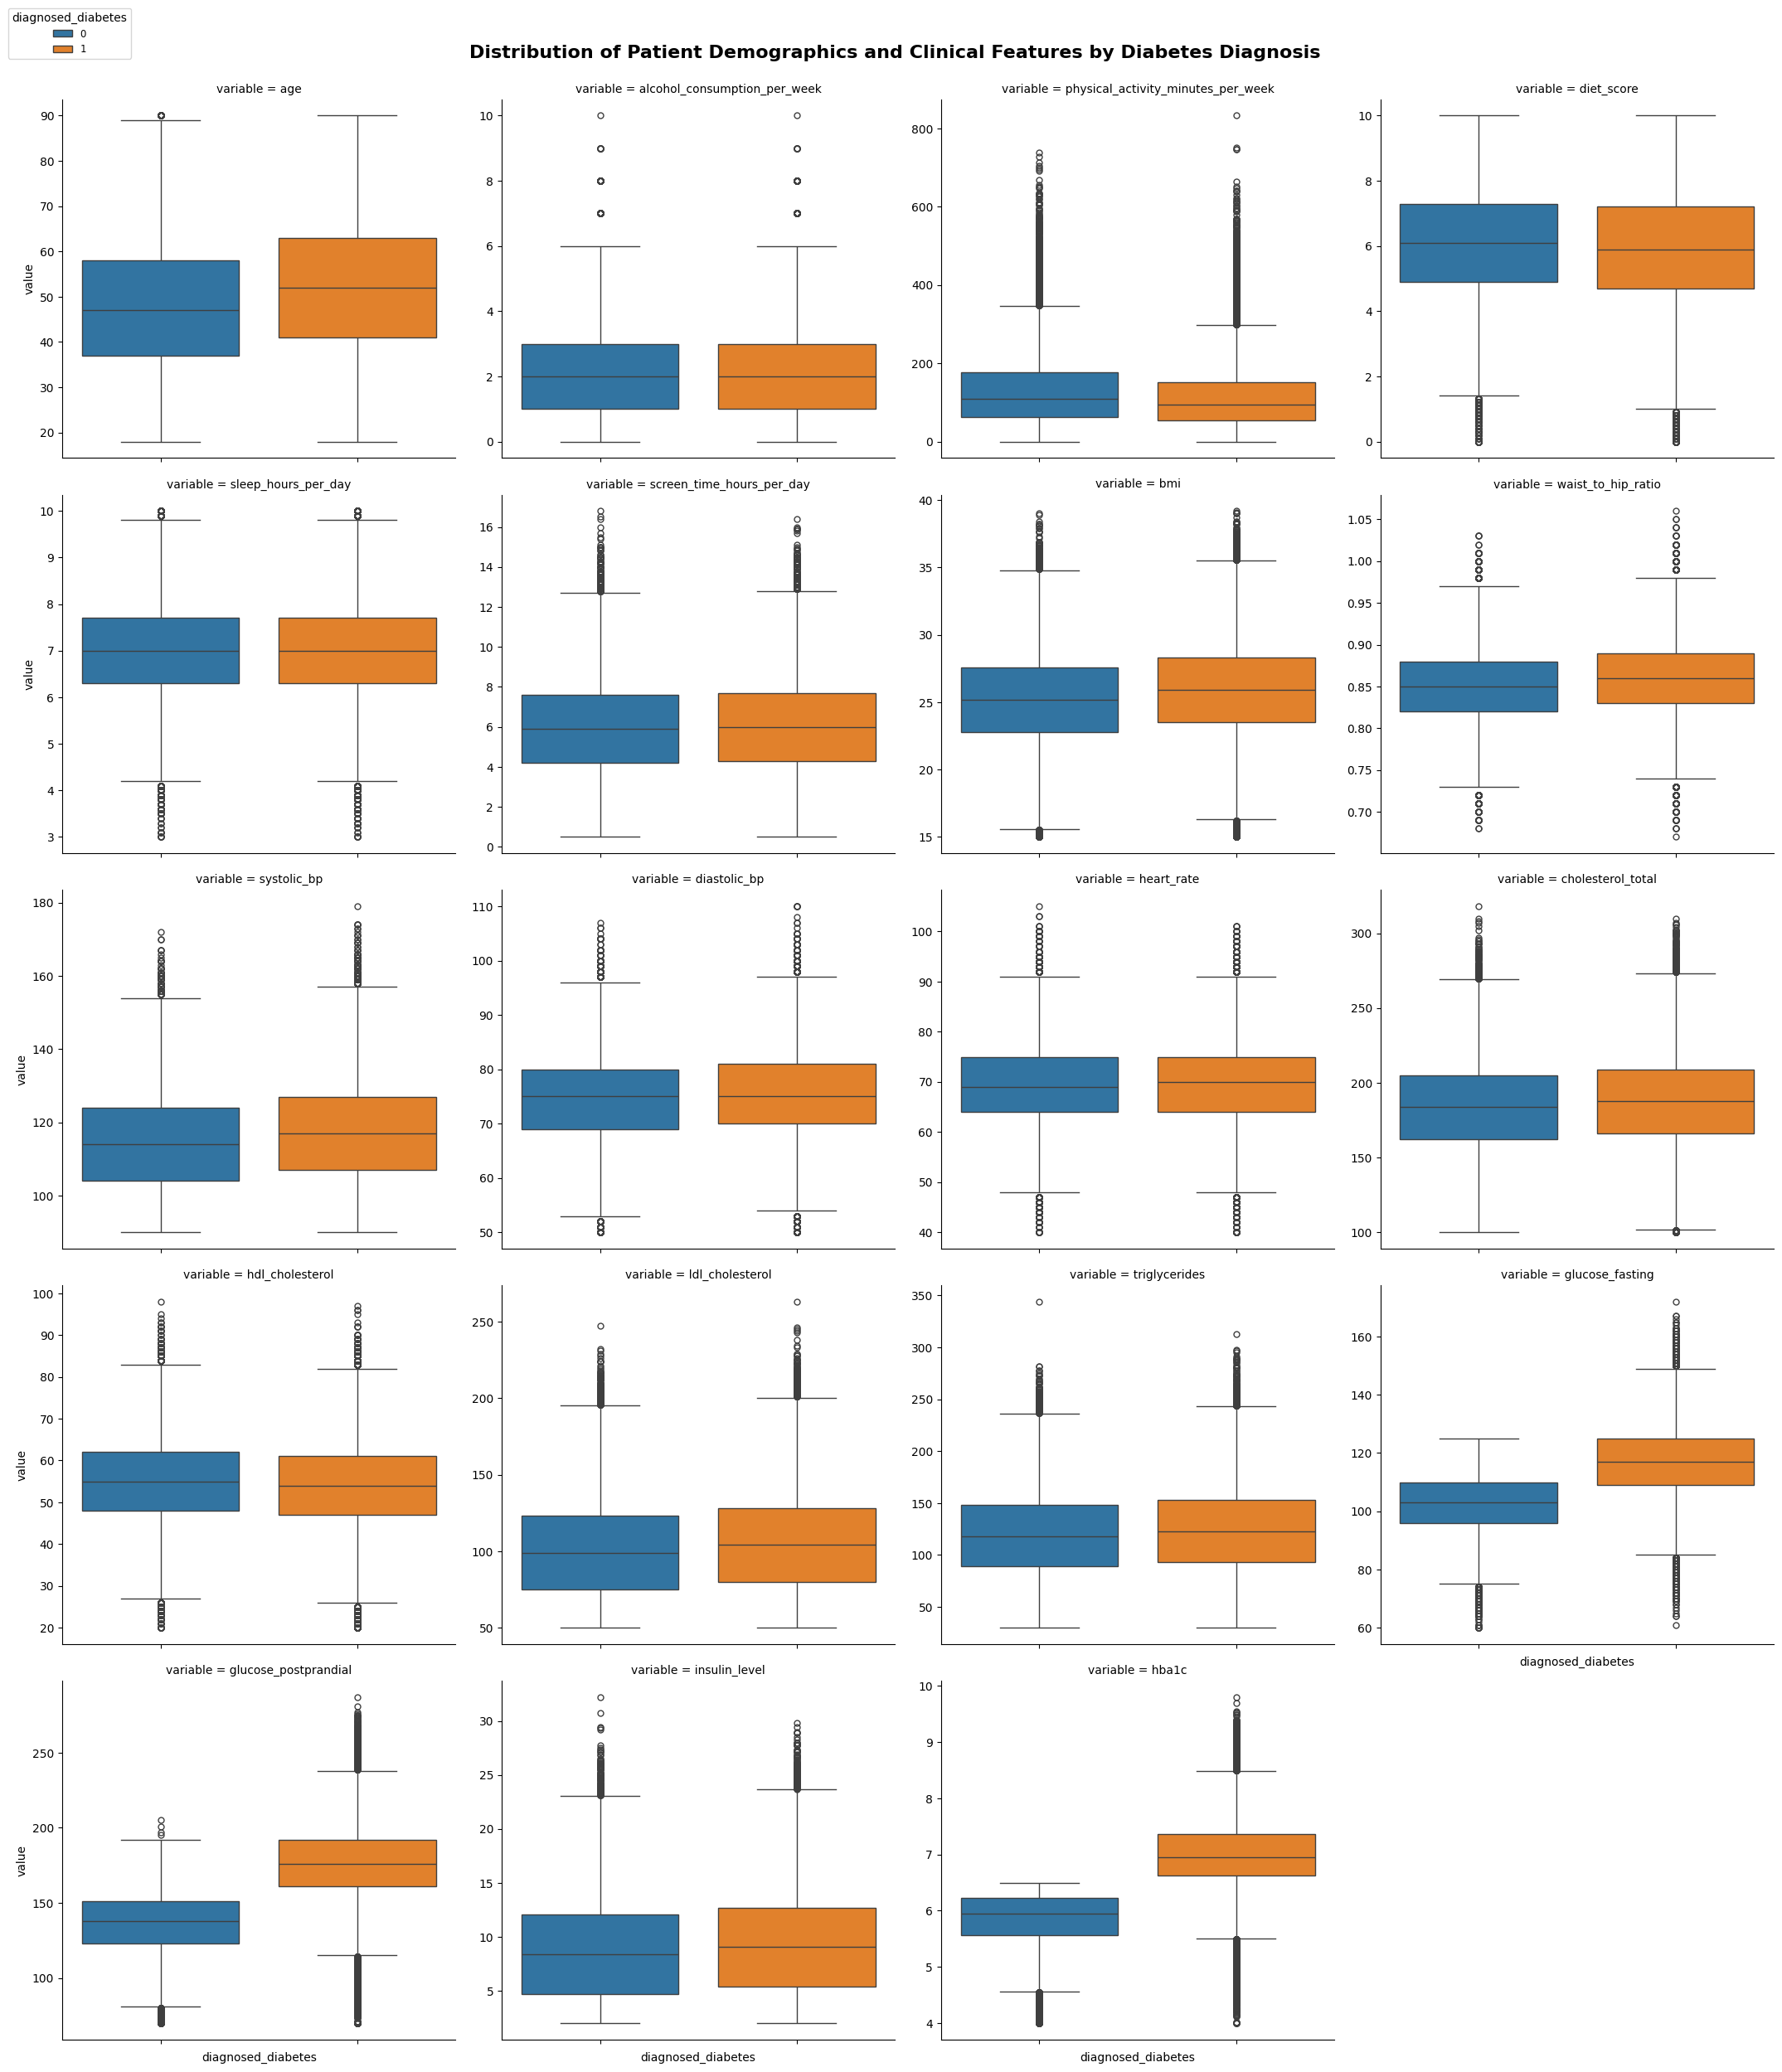

In [125]:
#Using catplot(boxplots) to check outliers and feature separation for Binary Classification

# Selecting numeric features and melting into a dataframe

numeric_cols = data.drop(columns = ["diabetes_risk_score"]).select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if data[col].nunique() > 2]
               
data_melt = data.melt(id_vars='diagnosed_diabetes', value_vars=numeric_cols)

# Using catplot to plot all boxplots in one command

b = sns.catplot(data=data_melt,
            x='diagnosed_diabetes',
            y='value', 
            col='variable',
            kind='box',
            col_wrap=4,
            sharey=False,
            hue = 'diagnosed_diabetes',
            legend = True
)

b.set(xticklabels=[])
sns.move_legend(b, loc="upper left", bbox_to_anchor=(0, 1), fontsize='small', title_fontsize='medium', frameon=True)
plt.suptitle("Distribution of Patient Demographics and Clinical Features by Diabetes Diagnosis\n\n", fontweight = "bold", fontsize = 16)
plt.tight_layout()

HbA1c and Glucose (Fasting & Postprandial) show the clearest box separation between classes, making them the most powerful predictors.

Many features have outliers, but these outliers could be clinically significant (representing severe cases), so not removing them.

Since KNN is distance-based, it is extremely critical to handle outliers. Approach: Log transformation followed by RobustScaler. 

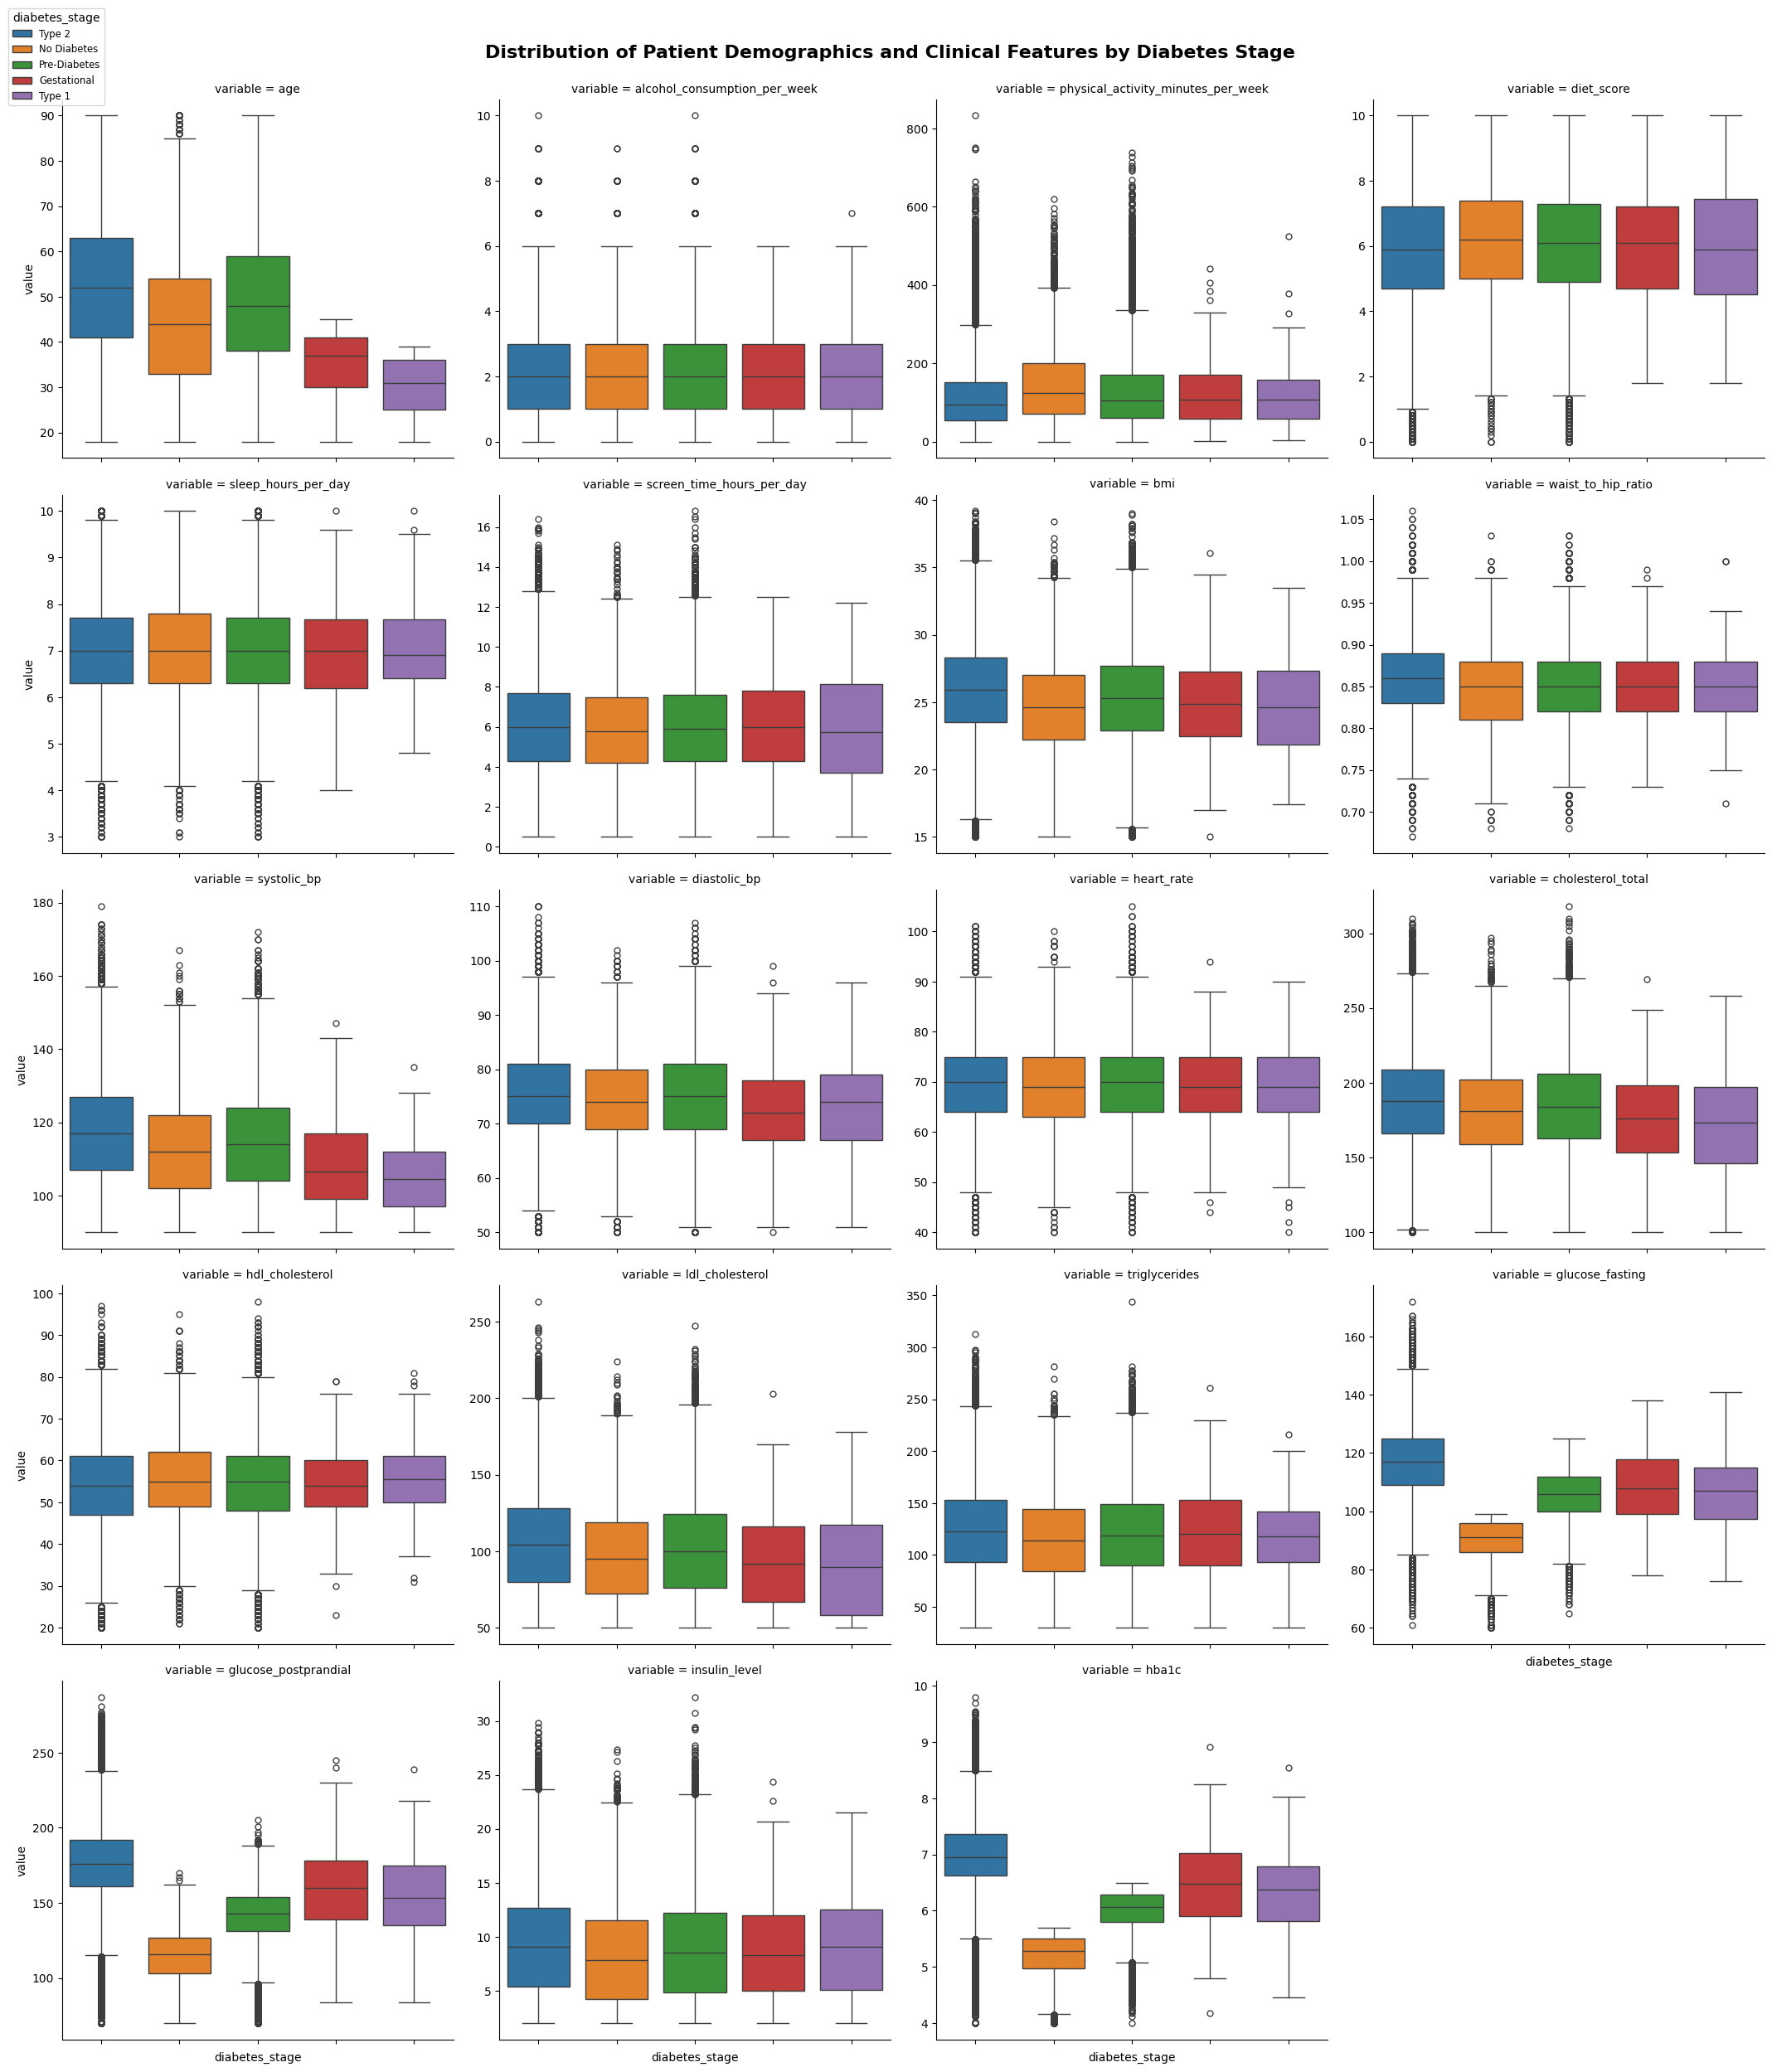

In [124]:
#Using catplot(boxplots) to check outliers and feature separation for Multi-Class Classification

# Selecting numeric features and melting into a dataframe

numeric_cols = data.drop(columns = ["diabetes_risk_score"]).select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if data[col].nunique() > 2]
               
data_melt = data.melt(id_vars='diabetes_stage', value_vars=numeric_cols)

# Using catplot to plot all boxplots in one command

ax = sns.catplot(data=data_melt,
            x='diabetes_stage',
            y='value', 
            col='variable',
            kind='box',
            col_wrap=4,
            sharey=False,
            hue = 'diabetes_stage',
            legend = True
)

ax.set(xticklabels=[])
sns.move_legend(ax, loc="upper left", bbox_to_anchor=(0, 1), fontsize='small', title_fontsize='medium', frameon=True)
plt.suptitle("Distribution of Patient Demographics and Clinical Features by Diabetes Stage\n\n", fontweight = "bold", fontsize = 16)
plt.tight_layout()

Again, HbA1c and Glucose (Fasting & Postprandial), along with age, show the most distinct separation between stages, making them the most powerful predictors for diabetes stage. 

Many features have outliers, but these outliers could be clinically significant (representing severe cases), so not removing them. Instead, taking Log transformation followed by RobustScaler. 

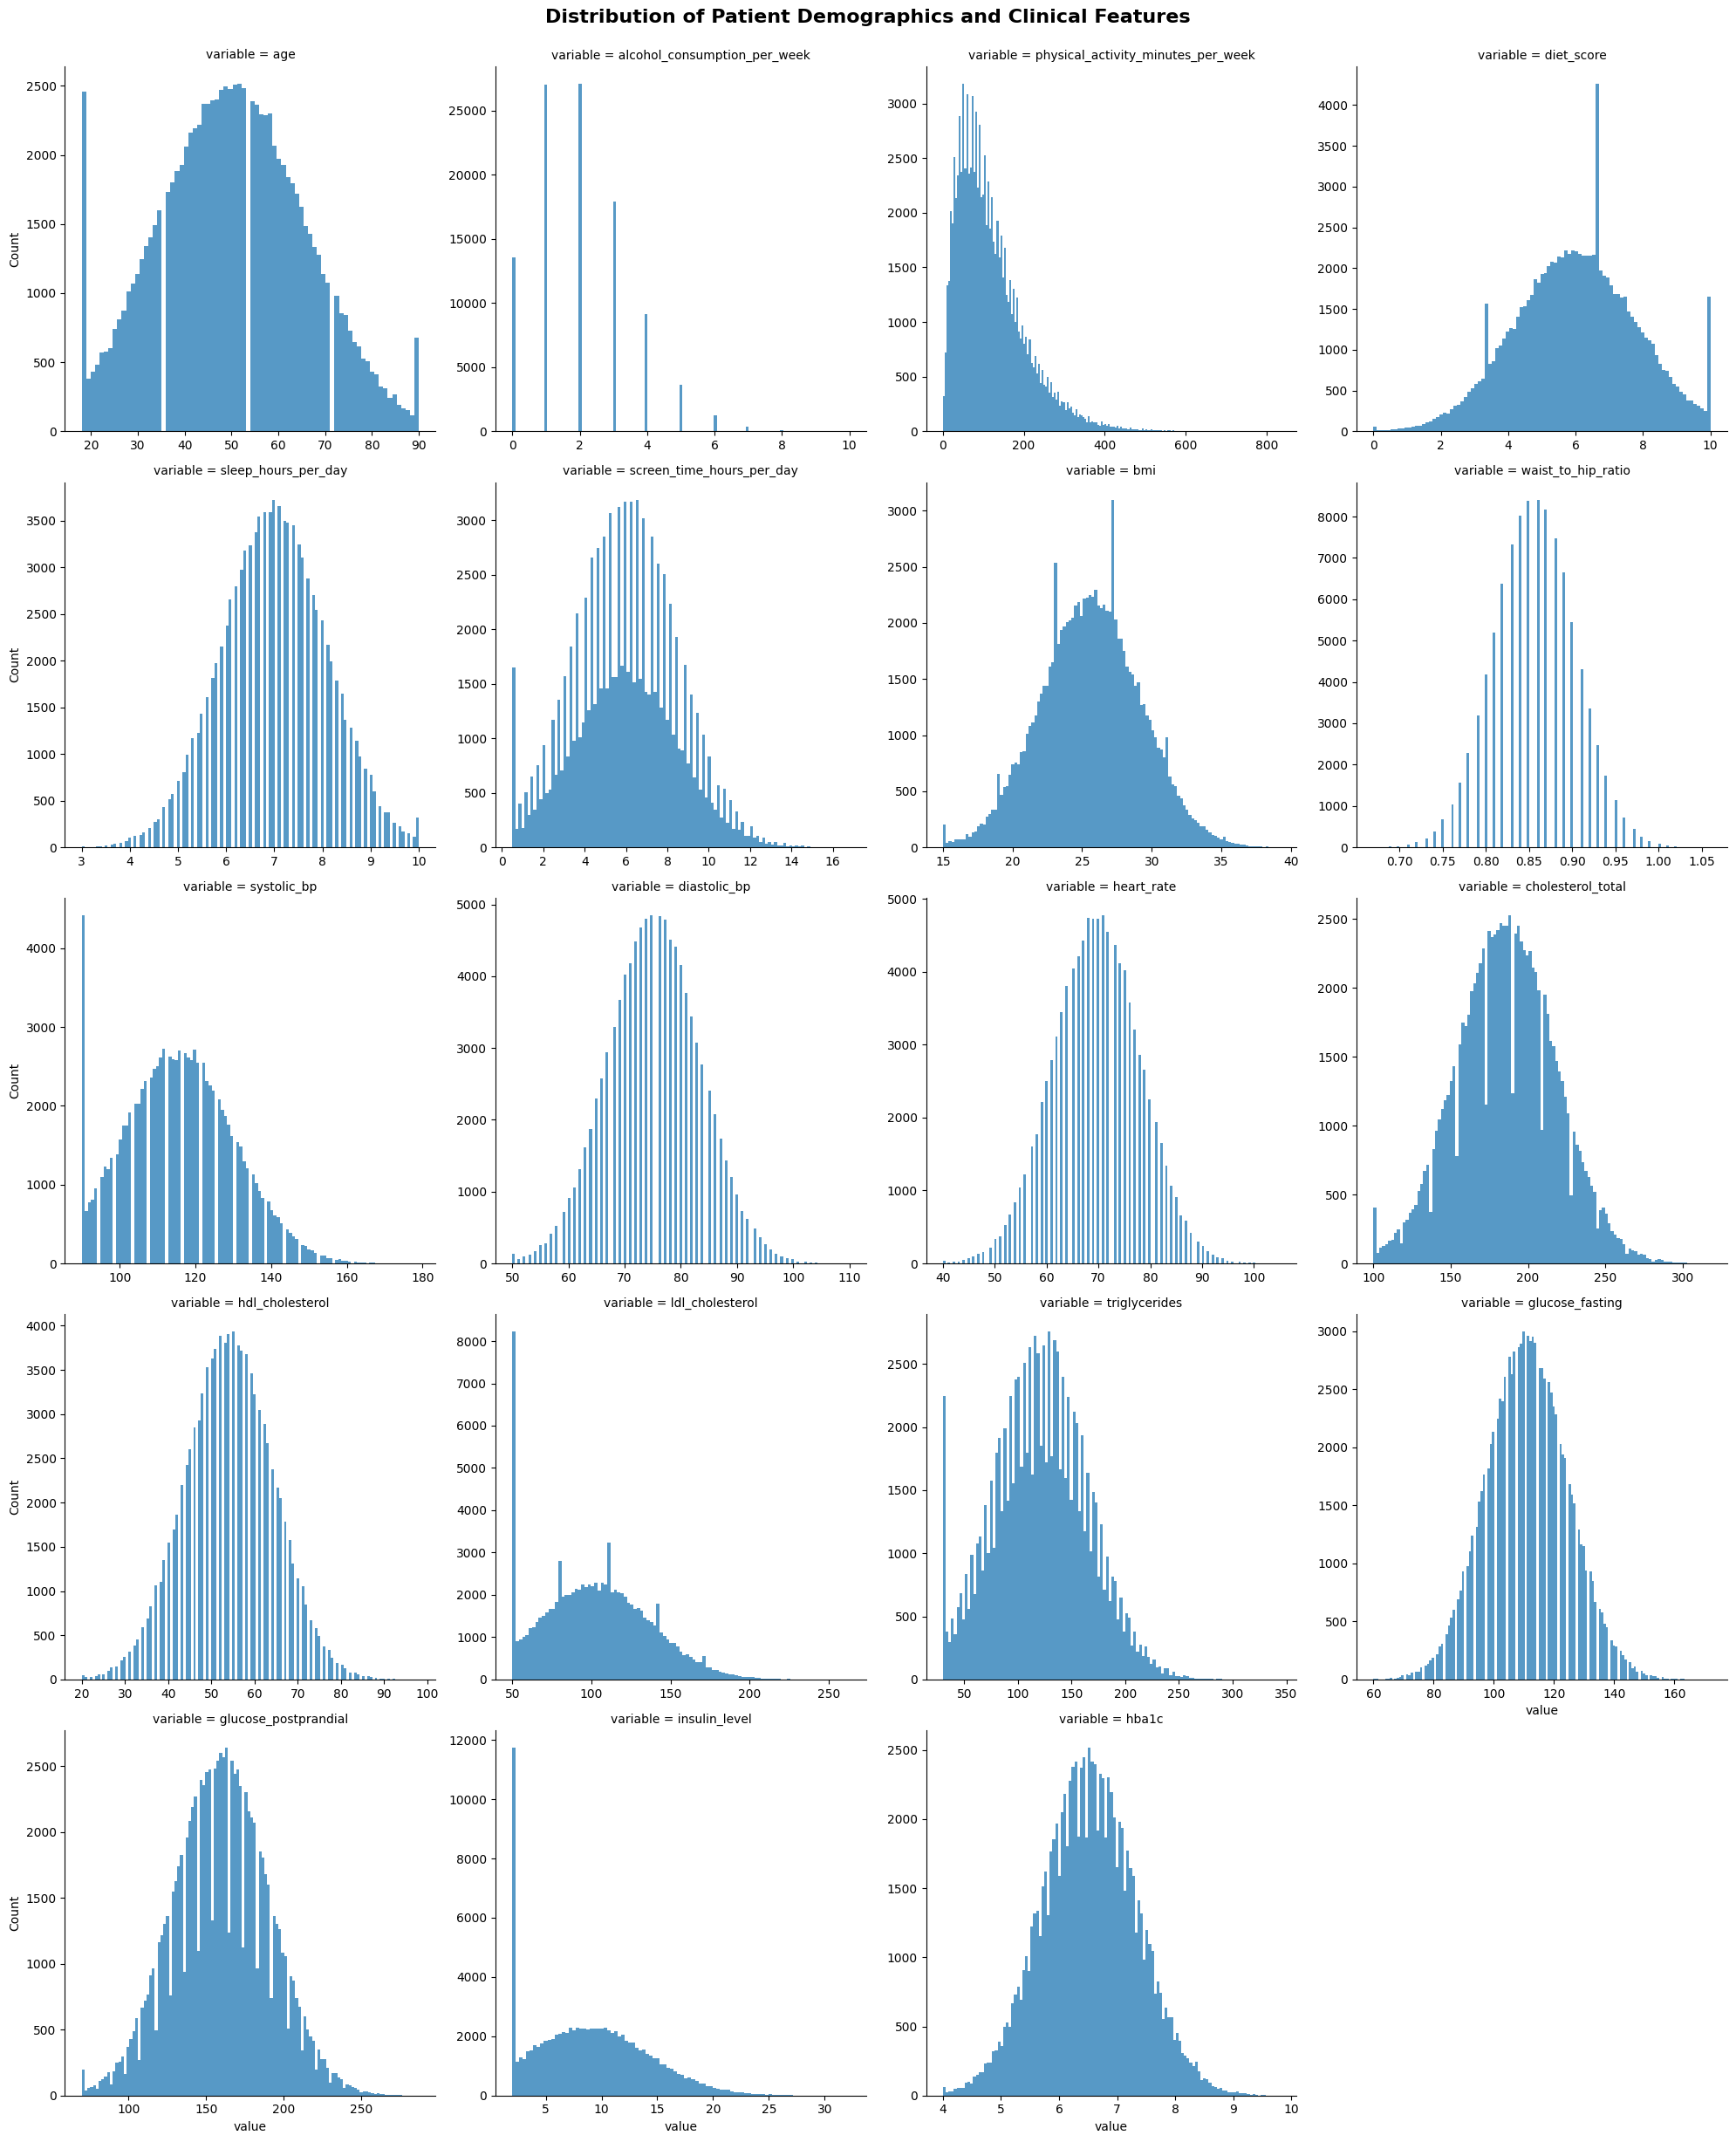

In [129]:
#Using distplot(histograms) to check feature distribution

# Selecting numeric features and melting into a dataframe

numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if data[col].nunique() > 2]
               
data_melt = data.melt(id_vars='diabetes_risk_score', value_vars=numeric_cols)


# Use displot for histograms across a grid

g = sns.displot(
    data = data_melt,
    x = 'value',           
    col = 'variable',      
    kind = 'hist',         
    col_wrap = 4,
    facet_kws = {'sharex': False, 'sharey': False},
    common_bins = False,
    common_norm = False
)

plt.suptitle("Distribution of Patient Demographics and Clinical Features\n\n", fontweight = "bold", fontsize = 16)
plt.tight_layout()

Most features are normally distributed. 

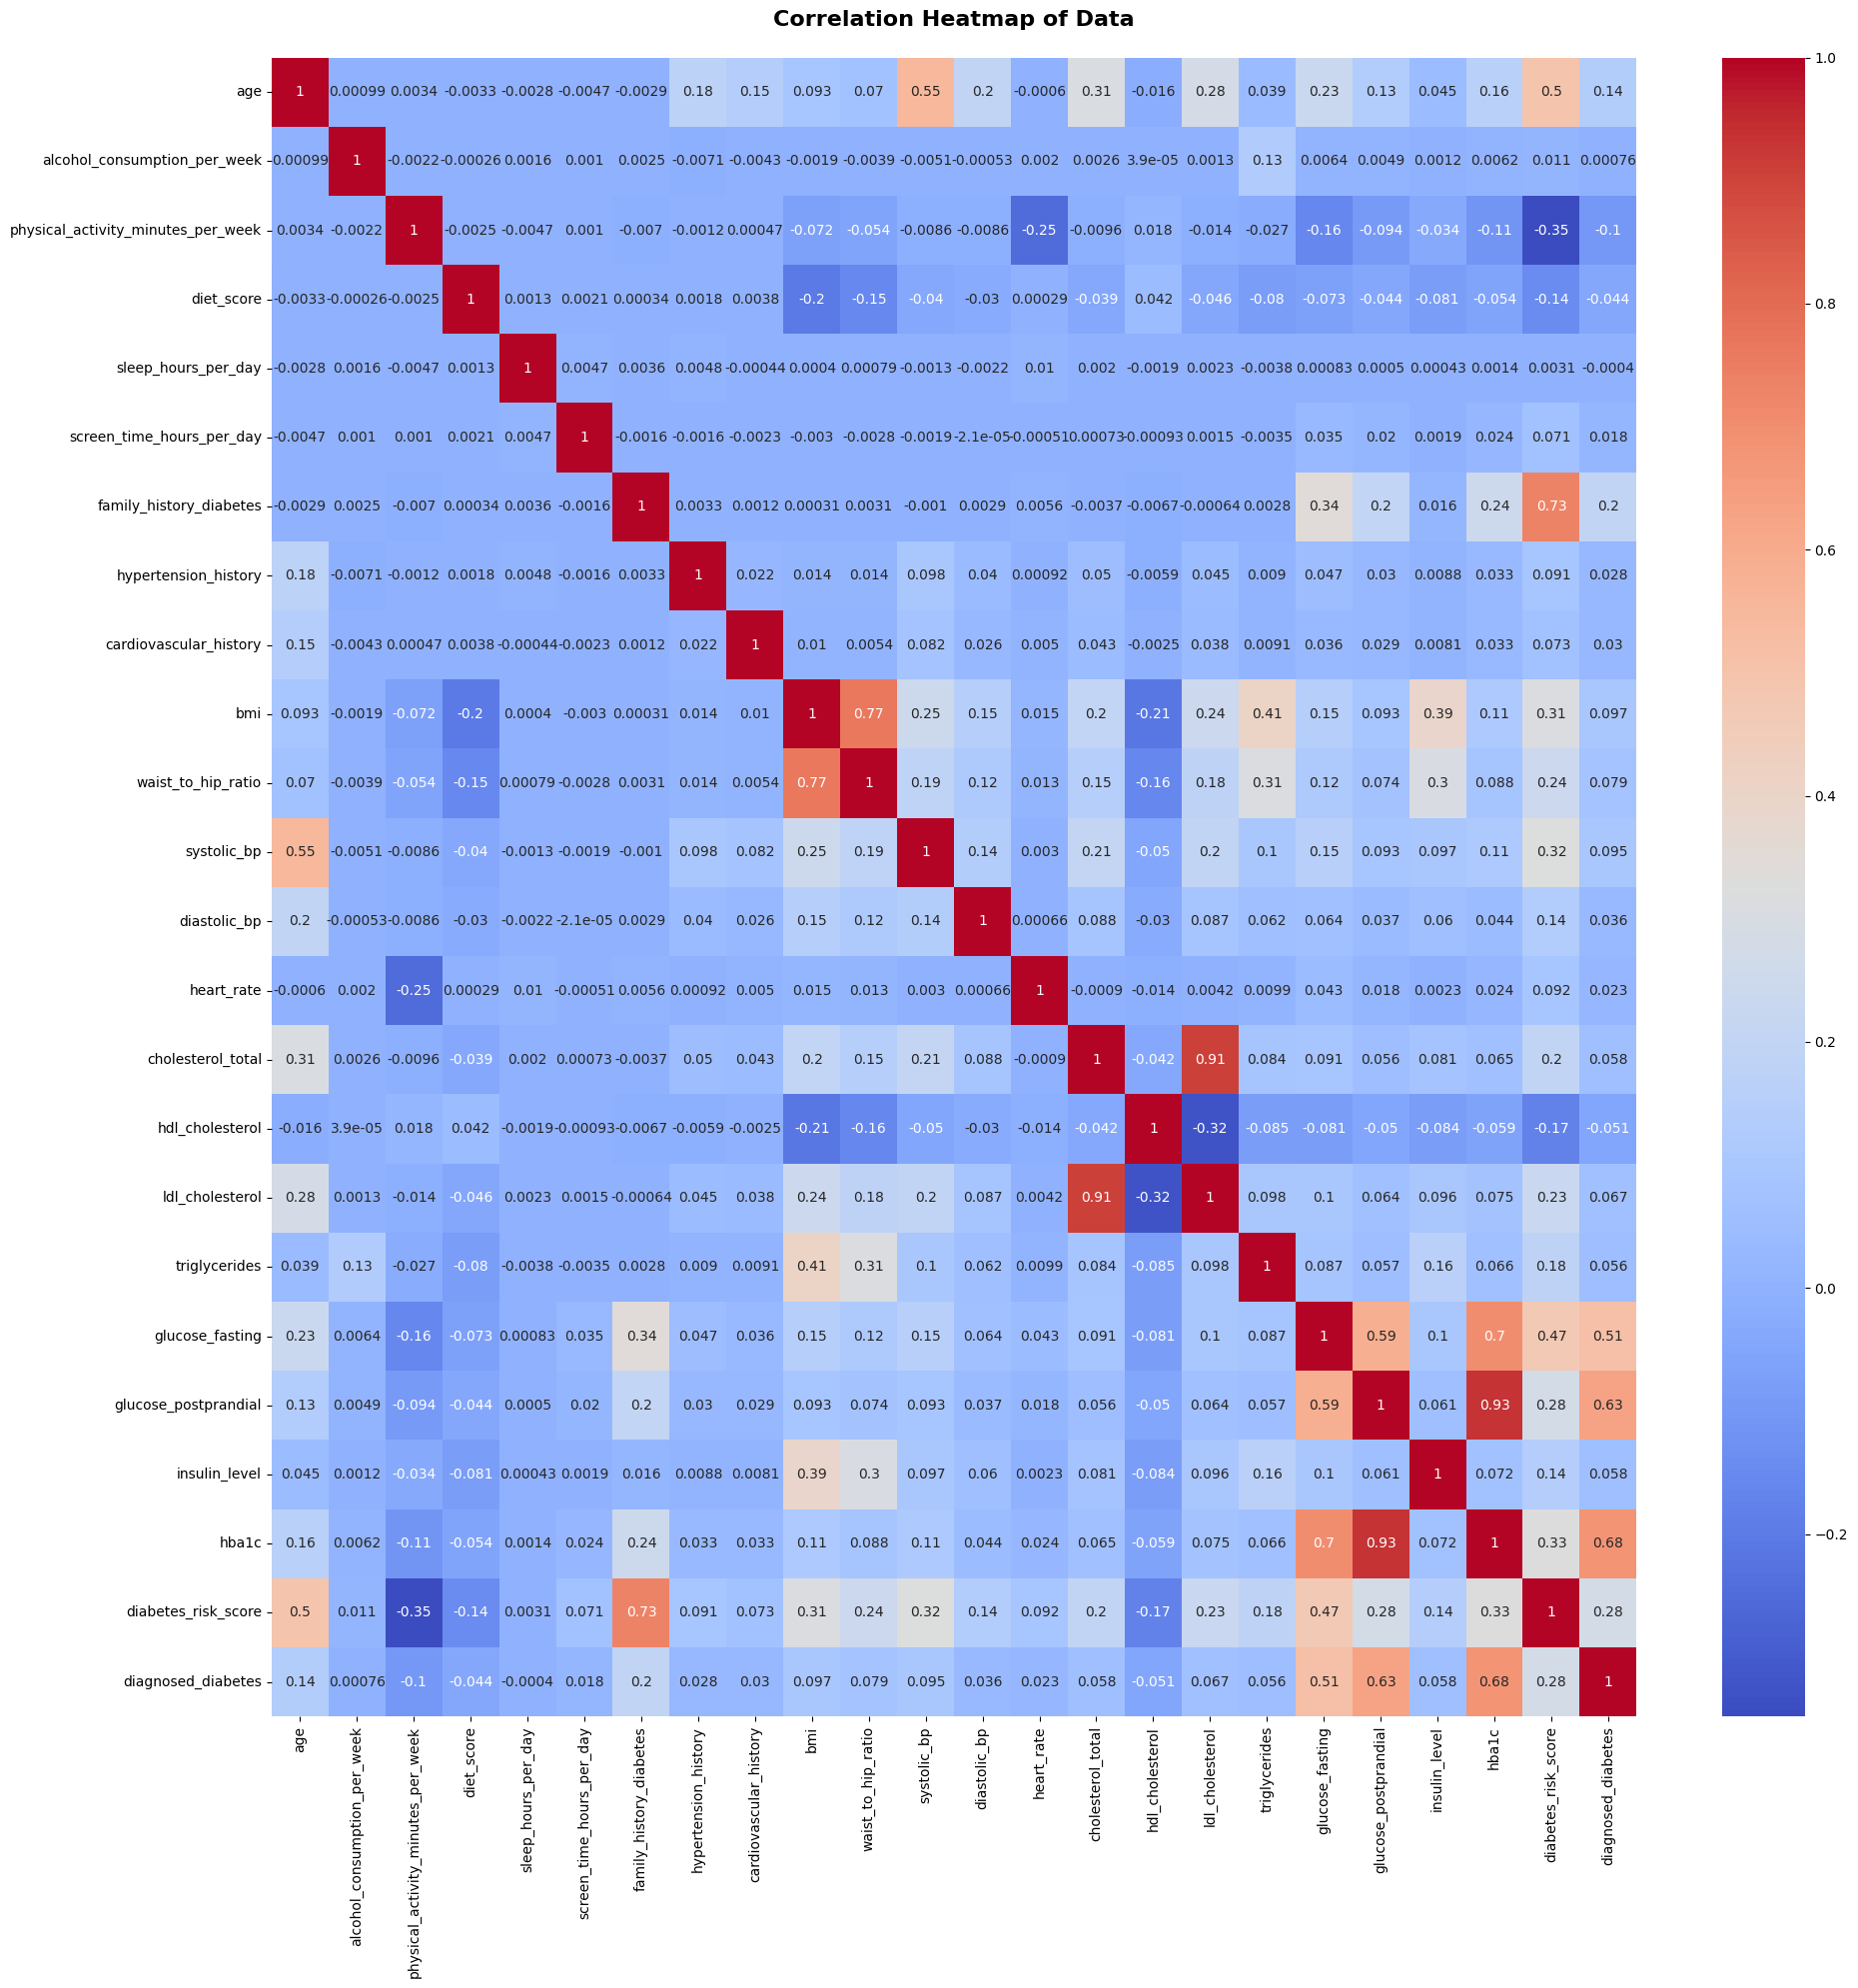

In [126]:
#Correlation Heatmap

plt.figure(figsize = (20, 20))

sns.heatmap(data.corr(),
           annot = True,
           cmap = "coolwarm")

plt.title("Correlation Heatmap of Data\n", fontweight = "bold", fontsize = 16)
plt.tight_layout()

HbA1c (0.68), Glucose Postprandial (0.63) and Glucose Fasting (0.51) are the strongest predictors, showing significant positive correlations with the diagnosed_diabetes target. High correlation between these features also suggests that these variables carry redundant information that may need addressing in certain models.

Family History (0.2) shows moderate positive correlations, confirming that clinical history aligns well with the actual diagnosis.

The heatmap shows a massive correlation between Family History (0.73) and the diabetes_risk_score, indicating history is the primary weight in this calculation.

Groupwise Comparisons (groupby mean table)

In [134]:
#Comparing means of key medical features (glucose fasting/postprandial, HbA1c and Age) by diabetes status


data.groupby("diagnosed_diabetes")["glucose_fasting", "glucose_postprandial", "hba1c", "age"].mean()



,glucose_fasting,glucose_postprandial,hba1c,age
diagnosed_diabetes,,,,
0,102.610119,136.173041,5.843554,47.488601
1,116.788926,175.944381,6.972295,51.875096


In [138]:
#Comparing means of key medical features (glucose fasting/postprandial, HbA1c and Age) by diabetes stage


data.groupby("diabetes_stage")["glucose_fasting", "glucose_postprandial", "hba1c", "age"].mean() 
                                  

,glucose_fasting,glucose_postprandial,hba1c,age
diabetes_stage,,,,
Gestational,108.568345,159.305755,6.465935,35.007194
No Diabetes,90.056133,114.572234,5.197990,44.334920
Pre-Diabetes,105.768975,141.579903,6.005346,48.363511
Type 1,106.680328,153.918033,6.339836,30.221311
Type 2,116.799344,175.953207,6.972617,51.939790


Data Preprocessing

Data Preparation

In [170]:
#Separating features and target

x = data.drop(columns = ["diagnosed_diabetes", "diabetes_stage", "diabetes_risk_score"])

#Binary Classification Target
y_binary = data["diagnosed_diabetes"]

#Multi-Class Classification Target 
#Label Encoding diabetes_stage target
y_multiple = data["diabetes_stage"]
le = LabelEncoder()
y_multiple = le.fit_transform(y_multiple)
y_multiple = pd.Series(y_multiple, name = 'diabetes_stage')

#Regression Target
y_reg = data["diabetes_risk_score"]

Splitting dataset

In [174]:
#Binary Classification with 80-20 split and stratify y
x_train_binary, x_test_binary, y_train_binary, y_test_binary = train_test_split(x, y_binary, test_size = 0.2, random_state = 42, stratify = y_binary)

#Multiple Classification with 80-20 split and stratify y 
x_train_multiple, x_test_multiple, y_train_multiple, y_test_multiple = train_test_split(x, y_multiple, test_size = 0.2, random_state = 42, stratify = y_multiple)

#Regression with 80-20 split
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y_reg, test_size = 0.2, random_state = 42)



Normalization (Encoding + Scaling)

In [205]:
#Ordinal Encoding some catagorical columns to preserve order
ord_cols = ["education_level", "income_level"]

#One-hot Encoding other catagorical columns
ohe_cols = ["gender", "ethnicity", "employment_status", "smoking_status"]

#Log Transformation followed by RobustScaler for numeric columns to handle outliers and scale
numeric_cols = data.drop(columns = ["diabetes_risk_score"]).select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols if data[col].nunique() > 2]

"""
numeric_pipeline = Pipeline([
                   ('log', FunctionTransformer(np.log1p, feature_names_out = 'one-to-one')),
                   ('scaler', RobustScaler())
                    
])

preprocessor = ColumnTransformer(
               transformers = [
                   ('num', numeric_pipeline, numeric_cols),
                   ('ord', OrdinalEncoder(categories = [["No formal", "Highschool", "Graduate", "Postgraduate"], 
                                                       ["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"]],
                                         handle_unknown = 'use_encoded_value', unknown_value = -1), ord_cols),
                   ('ohe', OneHotEncoder(drop = "first", handle_unknown = "ignore"), ohe_cols)
               ])

"""
from src.preprocessing import build_preprocessor

preprocessor = build_preprocessor(numeric_cols, ord_cols, ohe_cols)

preprocessor.fit(x_train_binary)

x_train_binary_proc = preprocessor.transform(x_train_binary)
x_test_binary_proc = preprocessor.transform(x_test_binary)

x_train_multiple_proc = preprocessor.transform(x_train_multiple)
x_test_multiple_proc = preprocessor.transform(x_test_multiple)

x_train_reg_proc = preprocessor.transform(x_train_reg)
x_test_reg_proc = preprocessor.transform(x_test_reg)

Handling Class Imbalance

In [198]:
#Using SMOTE-NC to oversample diabetes stage minority classes. Using the NC technique because data contains both catagorical and numerical columns.

#Getting catagorical indices
cat_indices = [i for i, name in enumerate(preprocessor.get_feature_names_out()) 
               if "ohe" in name or "ord" in name]

smote = SMOTENC(categorical_features = cat_indices, random_state = 42)

x_train_multiple_sm, y_train_multiple_sm = smote.fit_resample(x_train_multiple_proc, y_train_multiple)


In [204]:
#Importing the preprocessing function and checking it

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.preprocessing import build_preprocessor

# Dummy Lists
num_cols = ['BMI', 'PhysHlth'] 
ord_cols = ['Education', 'Income']
ohe_cols = ['GenHlth']

# Testing
try:
    preprocessor = build_preprocessor(num_cols, ord_cols, ohe_cols)
    print("Success! The function is correctly imported and running.")
except Exception as e:
    print(f"Error: {e}")

Success! The function is correctly imported and running.
